<a href="https://colab.research.google.com/github/Vitorms085/atividades-resolvidas-gsi073/blob/main/aula6_retrieval_augmented_generation_rag_alterado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 6: Introdução a RAG (Retrieval-Augmented Generation)

Objetivos:

- Entender o pipeline completo de um sistema RAG
- Implementar:
  - Chunking
  - Geração de embeddings
  - Busca vetorial por similaridade
  - Geração de resposta condicionada ao contexto recuperado
- Analisar como a recuperação influencia a qualidade da resposta


Nesta aula vamos usar o seguinte roteiro prático:

1. Criar uma mini base de conhecimento (docs).
2. Fazer *chunking* (segmentação) para obter unidades recuperáveis.
3. Gerar embeddings e implementar uma busca vetorial simples.
4. Montar o *contexto* (augmentation) com os chunks mais relevantes.
5. Passar o contexto para um modelo gerador (generator) e obter uma resposta (*RAG completo*).


## 1) Setup do ambiente


In [22]:
# Se necessário, instale as seguintes dependências:
# !pip install -U sentence-transformers transformers torch scikit-learn numpy pandas matplotlib

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch


## 2) Mini Base de Conhecimento


In [23]:
# Mini base de conhecimento (exemplo didático).
# Dica: substitua por trechos do seu domínio (FAQ, políticas, docs, etc.).

with open('/content/frases-rag-biblia.txt', 'r', encoding='utf-8') as f:
    ds = f.readlines()

docs = []

for i, line in enumerate(ds):
    docs.append({
          "id": 'doc' + str(i),
          "text": line
          })

print(docs)


[{'id': 'doc0', 'text': 'O Senhor é o meu pastor, nada me faltará.\n'}, {'id': 'doc1', 'text': 'Tudo posso naquele que me fortalece.\n'}, {'id': 'doc2', 'text': 'O amor nunca falha.\n'}, {'id': 'doc3', 'text': 'No princípio, criou Deus os céus e a terra.\n'}, {'id': 'doc4', 'text': 'Lâmpada para os meus pés é tua palavra e luz, para o meu caminho.\n'}, {'id': 'doc5', 'text': 'O que ganha almas sábio é.\n'}, {'id': 'doc6', 'text': 'Ainda que eu andasse pelo vale da sombra da morte, não temeria mal algum.\n'}, {'id': 'doc7', 'text': 'Deus é amor.\n'}, {'id': 'doc8', 'text': 'Buscai primeiro o reino de Deus e a sua justiça.\n'}, {'id': 'doc9', 'text': 'O coração alegre aformoseia o rosto.\n'}, {'id': 'doc10', 'text': 'Se Deus é por nós, quem será contra nós?\n'}, {'id': 'doc11', 'text': 'Eu sou o caminho, e a verdade e a vida.\n'}, {'id': 'doc12', 'text': 'A fé é o firme fundamento das coisas que se esperam.\n'}, {'id': 'doc13', 'text': 'Pedis, e dar-se-vos-á; buscai, e encontrareis.\n'},

## 3) Chunking (segmentação) - construção de contexto

Nesta aula, vamos usar sentenças como chunks (simples e didático).  
Em produção, você normalmente usa chunking por **tamanho** (tokens/caracteres) + **overlap**.


In [24]:
def split_sentences_pt(text: str) -> list[str]:
    # Segmentação simplificada (por ponto).
    return [s.strip() for s in text.split(".") if len(s.strip()) > 0]

rows = []
for doc in docs:
    sentences = split_sentences_pt(doc["text"])
    for sent in sentences:
        rows.append({
            "doc_id": doc["id"],
            "sentence": sent
        })

df = pd.DataFrame(rows)
df


,doc_id,sentence
0,doc0,"O Senhor é o meu pastor, nada me faltará"
1,doc1,Tudo posso naquele que me fortalece
2,doc2,O amor nunca falha
3,doc3,"No princípio, criou Deus os céus e a terra"
4,doc4,"Lâmpada para os meus pés é tua palavra e luz, ..."
...,...,...
95,doc95,A luz brilha nas trevas
96,doc96,"A vontade de Deus é boa, agradável e perfeita"
97,doc97,"Quem tem ouvidos para ouvir, ouça"
98,doc98,Preparaste uma mesa perante mim na presença do...


## 4) Gerar embeddings (Retriever, R do RAG)

Usaremos um modelo encoder-only do SentenceTransformers para gerar embeddings dos chunks.


In [25]:
model_emb = SentenceTransformer("all-MiniLM-L6-v2")

sentences = df["sentence"].tolist()
embeddings = model_emb.encode(sentences)

df["embedding"] = list(embeddings)
df.head()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,doc_id,sentence,embedding
0,doc0,"O Senhor é o meu pastor, nada me faltará","[-0.042687036, 0.09087807, -0.046729106, -0.01..."
1,doc1,Tudo posso naquele que me fortalece,"[0.065130964, 0.02917799, -0.0066890325, 0.062..."
2,doc2,O amor nunca falha,"[-0.034832463, -0.021515304, -0.043465465, 0.0..."
3,doc3,"No princípio, criou Deus os céus e a terra","[-0.009670047, 0.087904744, -0.005594833, -0.0..."
4,doc4,"Lâmpada para os meus pés é tua palavra e luz, ...","[-0.0019314738, 0.09415042, -0.020582343, -0.0..."


## 5) Busca vetorial por similaridade (R do RAG)

Implementação minimalista com similaridade cosseno.  
(Em produção, isso vai para um índice/banco vetorial: FAISS, Milvus, Pinecone, Weaviate, pgvector, etc.)


In [26]:
def retrieve(query: str, top_k: int = 3) -> pd.DataFrame:
    query_emb = model_emb.encode([query])
    matrix = np.vstack(df["embedding"].values)

    sims = cosine_similarity(query_emb, matrix)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]

    results = df.iloc[top_idx].copy()
    results["score"] = sims[top_idx]
    return results

query = "Quem é Deus ?"
retrieve(query, top_k=3)


,doc_id,sentence,embedding,score
10,doc10,"Se Deus é por nós, quem será contra nós?","[-0.019338299, 0.07359142, 0.02919879, -0.0355...",0.755171
88,doc88,Deus é fiel,"[-0.06322156, 0.05893263, 0.032070987, -0.0494...",0.715073
97,doc97,"Quem tem ouvidos para ouvir, ouça","[0.0023581057, 0.04091937, -0.04208072, -0.010...",0.653848


## 6) Montando o contexto (Augmentation, A do RAG)

Agora agregamos os chunks recuperados em um bloco de texto que será injetado no prompt.


In [27]:
def build_context(query: str, top_k: int = 3) -> str:
    retrieved = retrieve(query, top_k)
    context = "\n".join(retrieved["sentence"].tolist())
    return context

query = "O que é amor ?"
context = build_context(query, top_k=3)
print(context)


Deus é amor
Nisto conhecemos o amor: que Cristo deu a sua vida por nós
O amor seja não fingido


## 7) Parte gerativa (Generation, G do RAG)

Aqui usamos um modelo causal pequeno para fins didáticos. Troque o distilgpt2 para o gemma 3 para melhores resultados.


In [28]:
model_name = "distilgpt2" # Modelo pequeno para teste rápido
#model_name = "google/gemma-3-270m" # De melhor qualidade, mas download de 0.5G

tokenizer = AutoTokenizer.from_pretrained(model_name)
model_gen = AutoModelForCausalLM.from_pretrained(model_name)

# distilgpt-2 não tem pad_token necessário para a geração
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 8) Pipeline RAG simples

1. Recupera chunks (Retriever)  
2. Monta contexto (Augmentation)  
3. Gera resposta condicionada (Generator)


In [29]:
def rag_answer(query: str, top_k: int = 3, max_tokens: int = 150) -> str:
    context = build_context(query, top_k)

    prompt = f"""Responda à pergunta usando apenas o contexto abaixo.

Contexto:
{context}

Pergunta:
{query}

Resposta:
"""

    inputs = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True)

    with torch.no_grad():
        outputs = model_gen.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return answer

rag_answer("Quem é Deus?", top_k=3)


'Responda à pergunta usando apenas o contexto abaixo.\n\nContexto:\nSe Deus é por nós, quem será contra nós?\nDeus é fiel\nQuem tem ouvidos para ouvir, ouça\n\nPergunta:\nQuem é Deus?\n\nResposta:\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\nQuem é Deus?\n'

## 9) Visualizando similaridade (conexão com Embeddings)

Vamos projetar os embeddings em 2D com PCA para observar agrupamentos.


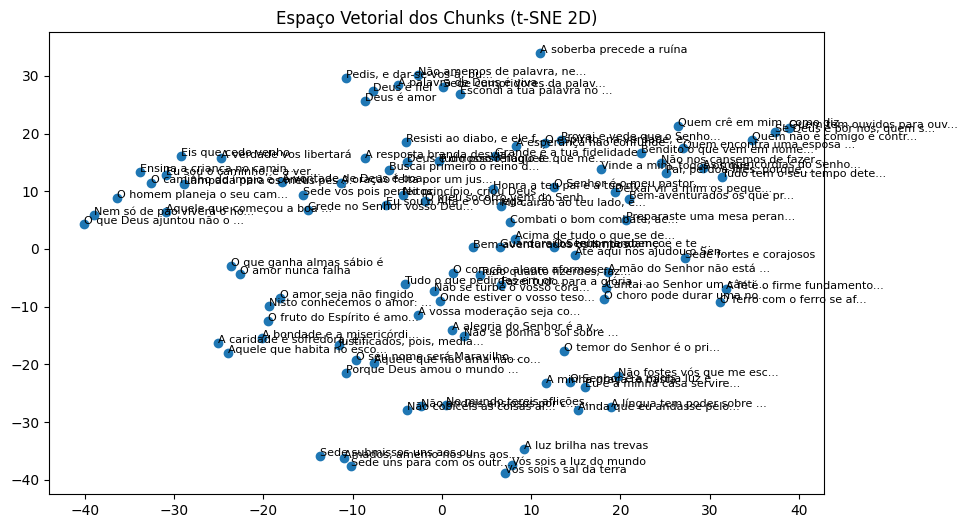

In [30]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE # Import TSNE
import matplotlib.pyplot as plt

X = np.vstack(df["embedding"].values)

# Use t-SNE instead of PCA
ts = TSNE(n_components=2, random_state=42, perplexity=5) # Added random_state for reproducibility and fixed perplexity
X2 = ts.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X2[:, 0], X2[:, 1])

for i, txt in enumerate(df["sentence"]):
    plt.annotate(txt[:25] + ("..." if len(txt) > 25 else ""), (X2[i, 0], X2[i, 1]), fontsize=8)

plt.title("Espaço Vetorial dos Chunks (t-SNE 2D)") # Update title
plt.show()

## 10) Experimentos

Tente rodar as células abaixo e discutir os resultados.

- O que acontece se `top_k = 1`?
- E se aumentarmos para `top_k = 5`?
- Faça uma pergunta fora do domínio da base (para ver como o sistema se comporta).
- Modifique os documentos e observe o impacto na resposta.
